# =============================================================================
# NOTEBOOK 4 — REGRESOR LSTM: PRONÓSTICO DE PRECIOS DE ACCIONES MINERAS
# Fases 1, 2 y 3: Flujo Completo Unificado y Listo para Ejecución
# =============================================================================

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Instalación e Importación de Librerías y Configuración de Entorno
# ─────────────────────────────────────────────────────────────────────────────
# !pip install yfinance --quiet

# !pip install yfinance --quiet

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import json
import os
import sys
from datetime import datetime, timedelta
from math import sqrt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Fijar semilla global para garantizar reproducibilidad exacta
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("=" * 66)
print("  NOTEBOOK 4 — REGRESOR LSTM: INICIALIZACIÓN GENERAL")
print("=" * 66)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  TensorFlow : {tf.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  yfinance   : {yf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"  GPU        : ✅ {gpus[0].name}" if gpus else "  GPU        : ⚠️ No detectada — se usará CPU")
print("=" * 66)

  NOTEBOOK 4 — REGRESOR LSTM: INICIALIZACIÓN GENERAL
  Python     : 3.12.13
  TensorFlow : 2.20.0
  pandas     : 2.2.2
  numpy      : 2.0.2
  yfinance   : 0.2.66
  GPU        : ⚠️ No detectada — se usará CPU


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Configuración Global de Hiperparámetros del Proyecto
# ─────────────────────────────────────────────────────────────────────────────
# Tickers oficiales de empresas mineras con operaciones en Perú (Fase 1 real)
TICKERS = [
    "FSM",          # Fortuna Silver Mines Inc. (NYSE)
    "VOLCABC1.LM",  # Volcan Compañía Minera S.A.A. (Bolsa de Lima)
    "ABX.TO",       # Barrick Gold Corporation (TSX Toronto)
    "BVN",          # Compañía de Minas Buenaventura S.A.A. (NYSE)
    "BHP",          # BHP Billiton Limited (NYSE)
]

# Configuración temporal y de partición
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=730)).strftime('%Y-%m-%d')

LOOKBACK_WINDOW = 60   # Ventana deslizante de 60 días (Requisito estricto)
TRAIN_RATIO     = 0.80 # Partición cronológica 80% entrenamiento / 20% prueba
TARGET_COLUMN   = 'Close'

# Hiperparámetros de la Red Neuronal (Fase 2)
EPOCHS        = 100
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3
LOSS_FUNCTION = 'mean_squared_error'
PATIENCE      = 15

LSTM_UNITS_1  = 64
LSTM_UNITS_2  = 32
DENSE_UNITS   = 16
DROPOUT_RATE  = 0.2

print(f"\n  Período configurado : {START_DATE} → {END_DATE}")
print(f"  Tickers del proyecto: {', '.join(TICKERS)}")
print("  Hiperparámetros de entrenamiento y arquitectura listos.")


  Período configurado : 2024-06-19 → 2026-06-19
  Tickers del proyecto: FSM, VOLCABC1.LM, ABX.TO, BVN, BHP
  Hiperparámetros de entrenamiento y arquitectura listos.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — FASE 1: Descarga Robusta de Datos desde Yahoo Finance
# ─────────────────────────────────────────────────────────────────────────────
def download_stock_data(tickers: list, start: str, end: str) -> dict:
    stock_data = {}
    print("\n📥 Iniciando descarga de datos históricos...\n")

    for ticker in tickers:
        try:
            print(f"  ⏳ Descargando: {ticker:<18}", end="", flush=True)
            df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

            if df.empty:
                print(f"  ⚠️ SIN DATOS — El ticker '{ticker}' no devolvió registros.")
                continue

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            rows_before = len(df)
            df.dropna(subset=[TARGET_COLUMN], inplace=True)

            min_required = LOOKBACK_WINDOW + 2
            if len(df) < min_required:
                print(f"  ⚠️ INSUFICIENTE — Solo {len(df)} filas (mínimo requerido: {min_required}).")
                continue

            stock_data[ticker] = df
            print(f"  ✅ OK — {len(df):>4} filas | Rango: {df.index[0].date()} → {df.index[-1].date()}")
        except Exception as e:
            print(f"  ❌ ERROR — {ticker}: {str(e)}")

    print(f"\n  Resumen: {len(stock_data)}/{len(tickers)} tickers descargados correctamente.")
    return stock_data

raw_data = download_stock_data(TICKERS, START_DATE, END_DATE)


📥 Iniciando descarga de datos históricos...

  ⏳ Descargando: FSM                 ✅ OK —  501 filas | Rango: 2024-06-20 → 2026-06-18
  ⏳ Descargando: VOLCABC1.LM         ✅ OK —  494 filas | Rango: 2024-06-20 → 2026-06-18
  ⏳ Descargando: ABX.TO              ✅ OK —  502 filas | Rango: 2024-06-19 → 2026-06-18
  ⏳ Descargando: BVN                 ✅ OK —  501 filas | Rango: 2024-06-20 → 2026-06-18
  ⏳ Descargando: BHP                 ✅ OK —  501 filas | Rango: 2024-06-20 → 2026-06-18

  Resumen: 5/5 tickers descargados correctamente.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — FASE 1: Funciones de Secuenciación y División Cronológica
# ─────────────────────────────────────────────────────────────────────────────
def create_sequences(scaled_data: np.ndarray, lookback: int = LOOKBACK_WINDOW) -> tuple:
    X_list, y_list = [], []
    for i in range(lookback, len(scaled_data)):
        X_list.append(scaled_data[i - lookback:i, 0])
        y_list.append(scaled_data[i, 0])
    X = np.array(X_list)
    y = np.array(y_list)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, y

def split_train_test(X: np.ndarray, y: np.ndarray, train_ratio: float = TRAIN_RATIO) -> tuple:
    split_idx = int(len(X) * train_ratio)
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:], split_idx

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — FASE 1: Pipeline Completo de Preprocesamiento por Ticker
# ─────────────────────────────────────────────────────────────────────────────
def build_dataset_pipeline(stock_data: dict) -> dict:
    processed = {}
    print("\n" + "=" * 60)
    print("  PIPELINE DE PREPROCESAMIENTO (FASE 1 REAL)")
    print("=" * 60)

    for ticker, df in stock_data.items():
        print(f"\n  📊 Procesando: {ticker}\n  {'─' * 50}")
        try:
            close_prices = df[TARGET_COLUMN].values.astype(float)
            dates        = df.index

            n_total = len(close_prices)
            approx_train_end = int((n_total - LOOKBACK_WINDOW) * TRAIN_RATIO) + LOOKBACK_WINDOW

            scaler = MinMaxScaler(feature_range=(0, 1))
            scaler.fit(close_prices[:approx_train_end].reshape(-1, 1))
            scaled_prices = scaler.transform(close_prices.reshape(-1, 1))

            X, y = create_sequences(scaled_prices, lookback=LOOKBACK_WINDOW)
            X_train, X_test, y_train, y_test, split_idx = split_train_test(X, y, TRAIN_RATIO)

            dates_test_pool = dates[LOOKBACK_WINDOW:]
            dates_test_real = dates_test_pool[split_idx:]

            processed[ticker] = {
                'X_train': X_train, 'X_test': X_test,
                'y_train': y_train, 'y_test': y_test,
                'scaler': scaler, 'close_prices': close_prices,
                'split_index': split_idx, 'dates': dates,
                'dates_test': dates_test_real.strftime('%Y-%m-%d').tolist()
            }
            print(f"  ✅ {ticker} procesado: Train {X_train.shape} | Test {X_test.shape}")
        except Exception as e:
            print(f"  ❌ Error procesando {ticker}: {str(e)}")
    print("\n" + "=" * 60)
    return processed

datasets = build_dataset_pipeline(raw_data)


  PIPELINE DE PREPROCESAMIENTO (FASE 1 REAL)

  📊 Procesando: FSM
  ──────────────────────────────────────────────────
  ✅ FSM procesado: Train (352, 60, 1) | Test (89, 60, 1)

  📊 Procesando: VOLCABC1.LM
  ──────────────────────────────────────────────────
  ✅ VOLCABC1.LM procesado: Train (347, 60, 1) | Test (87, 60, 1)

  📊 Procesando: ABX.TO
  ──────────────────────────────────────────────────
  ✅ ABX.TO procesado: Train (353, 60, 1) | Test (89, 60, 1)

  📊 Procesando: BVN
  ──────────────────────────────────────────────────
  ✅ BVN procesado: Train (352, 60, 1) | Test (89, 60, 1)

  📊 Procesando: BHP
  ──────────────────────────────────────────────────
  ✅ BHP procesado: Train (352, 60, 1) | Test (89, 60, 1)



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — FASE 2: Constructor de la Red Neuronal Regresora LSTM Stacked
# ─────────────────────────────────────────────────────────────────────────────
def build_lstm_regressor(input_shape: tuple) -> Sequential:
    model = Sequential(name="LSTM_Regressor_Mineras")

    # Capa 1: Stacked LSTM
    model.add(LSTM(units=LSTM_UNITS_1, return_sequences=True, input_shape=input_shape, name="lstm_1"))
    model.add(Dropout(rate=DROPOUT_RATE, name="dropout_1"))

    # Capa 2: LSTM de consolidación
    model.add(LSTM(units=LSTM_UNITS_2, return_sequences=False, name="lstm_2"))
    model.add(Dropout(rate=DROPOUT_RATE, name="dropout_2"))

    # Capa Intermedia y Salida Lineal
    model.add(Dense(units=DENSE_UNITS, activation='relu', name="dense_hidden"))
    model.add(Dense(units=1, activation='linear', name="output"))

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss=LOSS_FUNCTION, metrics=['mae'])
    return model

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — FASE 2: Bucle de Entrenamiento Automático con Early Stopping
# ─────────────────────────────────────────────────────────────────────────────
def train_all_models(datasets: dict) -> dict:
    n_tickers = len(datasets)
    print("\n" + "=" * 62)
    print("  ENTRENAMIENTO DE MODELOS LSTM (FASE 2)")
    print(f"  Entrenando {n_tickers} modelos independientes...")
    print("=" * 62)

    for idx, (ticker, data) in enumerate(datasets.items(), start=1):
        print(f"\n  [{idx}/{n_tickers}] Entrenando modelo para: {ticker}")
        print(f"  {'─' * 55}")

        X_train, y_train = data['X_train'], data['y_train']
        X_test, y_test   = data['X_test'], data['y_test']
        input_shape      = (X_train.shape[1], X_train.shape[2])

        model = build_lstm_regressor(input_shape=input_shape)
        early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=0)

        history = model.fit(
            X_train, y_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_test, y_test),
            callbacks=[early_stop], verbose=0
        )

        print(f"  ✅ {ticker} — Completado en {len(history.history['loss'])} épocas.")
        data['model']   = model
        data['history'] = history

    print("\n" + "=" * 62)
    return datasets

datasets = train_all_models(datasets)


  ENTRENAMIENTO DE MODELOS LSTM (FASE 2)
  Entrenando 5 modelos independientes...

  [1/5] Entrenando modelo para: FSM
  ───────────────────────────────────────────────────────
  ✅ FSM — Completado en 100 épocas.

  [2/5] Entrenando modelo para: VOLCABC1.LM
  ───────────────────────────────────────────────────────
  ✅ VOLCABC1.LM — Completado en 100 épocas.

  [3/5] Entrenando modelo para: ABX.TO
  ───────────────────────────────────────────────────────
  ✅ ABX.TO — Completado en 64 épocas.

  [4/5] Entrenando modelo para: BVN
  ───────────────────────────────────────────────────────
  ✅ BVN — Completado en 16 épocas.

  [5/5] Entrenando modelo para: BHP
  ───────────────────────────────────────────────────────
  ✅ BHP — Completado en 25 épocas.



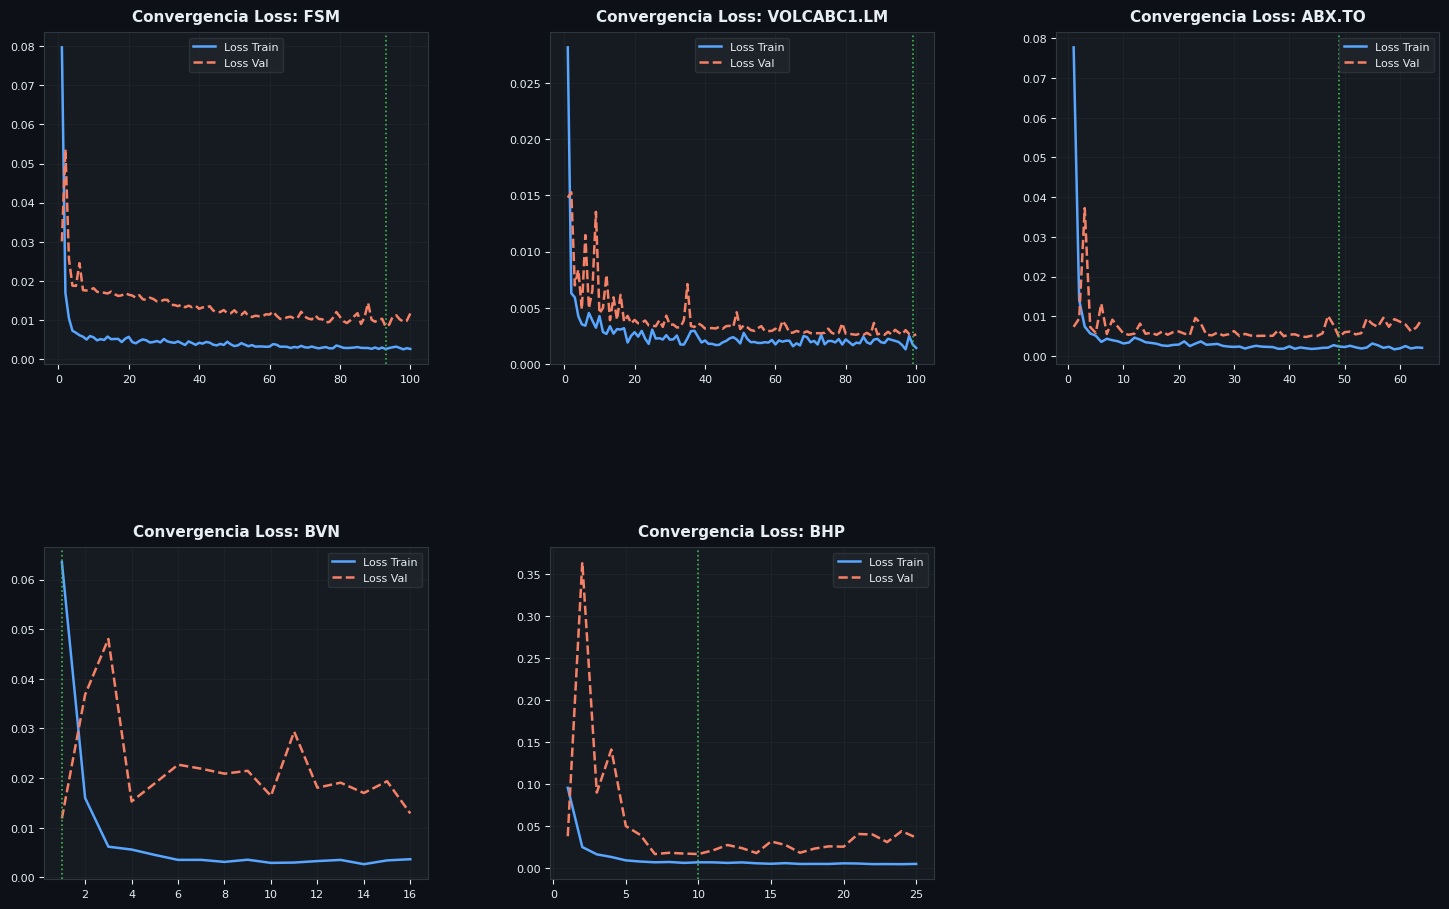

In [ ]:
# Crea una celda nueva y pega este código:
def plot_loss_curves(datasets: dict) -> None:
    BG_MAIN, BG_SUBPLOT = '#0d1117', '#161b22'
    C_TRAIN, C_VAL, C_BEST = '#58a6ff', '#f78166', '#3fb950'
    C_TEXT, C_GRID, C_BORDER = '#e6edf3', '#21262d', '#30363d'

    tickers_list = list(datasets.keys())
    nrows = int(np.ceil(len(tickers_list) / 3))
    fig = plt.figure(figsize=(18, 5.5 * nrows), facecolor=BG_MAIN)
    gs = gridspec.GridSpec(nrows, 3, figure=fig, hspace=0.55, wspace=0.32)

    for i, ticker in enumerate(tickers_list):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        ax.set_facecolor(BG_SUBPLOT)
        for spine in ax.spines.values(): spine.set_edgecolor(C_BORDER)

        history = datasets[ticker]['history']
        train_loss = history.history['loss']
        val_loss = history.history['val_loss']
        epoch_axis = range(1, len(train_loss) + 1)
        best_epoch = int(np.argmin(val_loss)) + 1

        ax.plot(epoch_axis, train_loss, color=C_TRAIN, linewidth=1.8, label='Loss Train')
        ax.plot(epoch_axis, val_loss, color=C_VAL, linewidth=1.8, linestyle='--', label='Loss Val')
        ax.axvline(x=best_epoch, color=C_BEST, linewidth=1.2, linestyle=':')
        ax.set_title(f'Convergencia Loss: {ticker}', color=C_TEXT, fontsize=11, fontweight='bold', pad=8)
        ax.grid(True, color=C_GRID, linestyle='-', linewidth=0.5)
        ax.tick_params(colors=C_TEXT, labelsize=8)
        ax.legend(facecolor='#21262d', edgecolor=C_BORDER, labelcolor=C_TEXT, fontsize=8)
    plt.show()

plot_loss_curves(datasets)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — FASE 3: Inferencia y Desnormalización de Precios a USD Reales
# ─────────────────────────────────────────────────────────────────────────────
def run_inference(datasets: dict) -> dict:
    print("\n" + "=" * 66)
    print("  INFERENCIA Y DESNORMALIZACIÓN NOMINAL (FASE 3)")
    print("=" * 66)

    for ticker, data in datasets.items():
        model  = data['model']
        scaler = data['scaler']
        X_test = data['X_test']
        y_test = data['y_test']

        y_pred_scaled = model.predict(X_test, verbose=0)

        data['y_pred_real'] = scaler.inverse_transform(y_pred_scaled).flatten()
        data['y_test_real'] = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        print(f"  ✅ {ticker:<12} — Inferencia completada con éxito.")
    print("=" * 66)
    return datasets

datasets = run_inference(datasets)


  INFERENCIA Y DESNORMALIZACIÓN NOMINAL (FASE 3)
  ✅ FSM          — Inferencia completada con éxito.
  ✅ VOLCABC1.LM  — Inferencia completada con éxito.
  ✅ ABX.TO       — Inferencia completada con éxito.
  ✅ BVN          — Inferencia completada con éxito.
  ✅ BHP          — Inferencia completada con éxito.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — FASE 3: Evaluación de Métricas Financieras (RMSE, MAE, MAPE)
# ─────────────────────────────────────────────────────────────────────────────
EPSILON = 1e-8

def compute_metrics(datasets: dict) -> dict:
    metrics_summary = {}
    print("\n" + "=" * 66)
    print("  TABLA DE MÉTRICAS — EVALUACIÓN DEL REGRESOR")
    print("=" * 66)
    print(f"\n  {'Ticker':<14} {'RMSE (USD)':>12} {'MAE (USD)':>12} {'MAPE (%)':>10}")
    print(f"  {'─'*14} {'─'*12} {'─'*12} {'─'*10}")

    for ticker, data in datasets.items():
        y_true = data['y_test_real']
        y_pred = data['y_pred_real']

        rmse = sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPSILON))) * 100)

        print(f"  {ticker:<14} {rmse:>12.4f} {mae:>12.4f} {mape:>10.2f}%")

        data['metrics'] = { 'rmse': rmse, 'mae': mae, 'mape': mape }
        metrics_summary[ticker] = { 'rmse': round(rmse, 6), 'mae': round(mae, 6), 'mape': round(mape, 4) }
    print("=" * 66)
    return metrics_summary

metrics_all = compute_metrics(datasets)


  TABLA DE MÉTRICAS — EVALUACIÓN DEL REGRESOR

  Ticker           RMSE (USD)    MAE (USD)   MAPE (%)
  ────────────── ──────────── ──────────── ──────────
  FSM                  0.7022       0.5133       4.89%
  VOLCABC1.LM          0.0405       0.0312       4.26%
  ABX.TO               3.4281       2.7900       4.71%
  BVN                  2.9497       2.3455       7.04%
  BHP                  4.1118       3.4525       4.48%


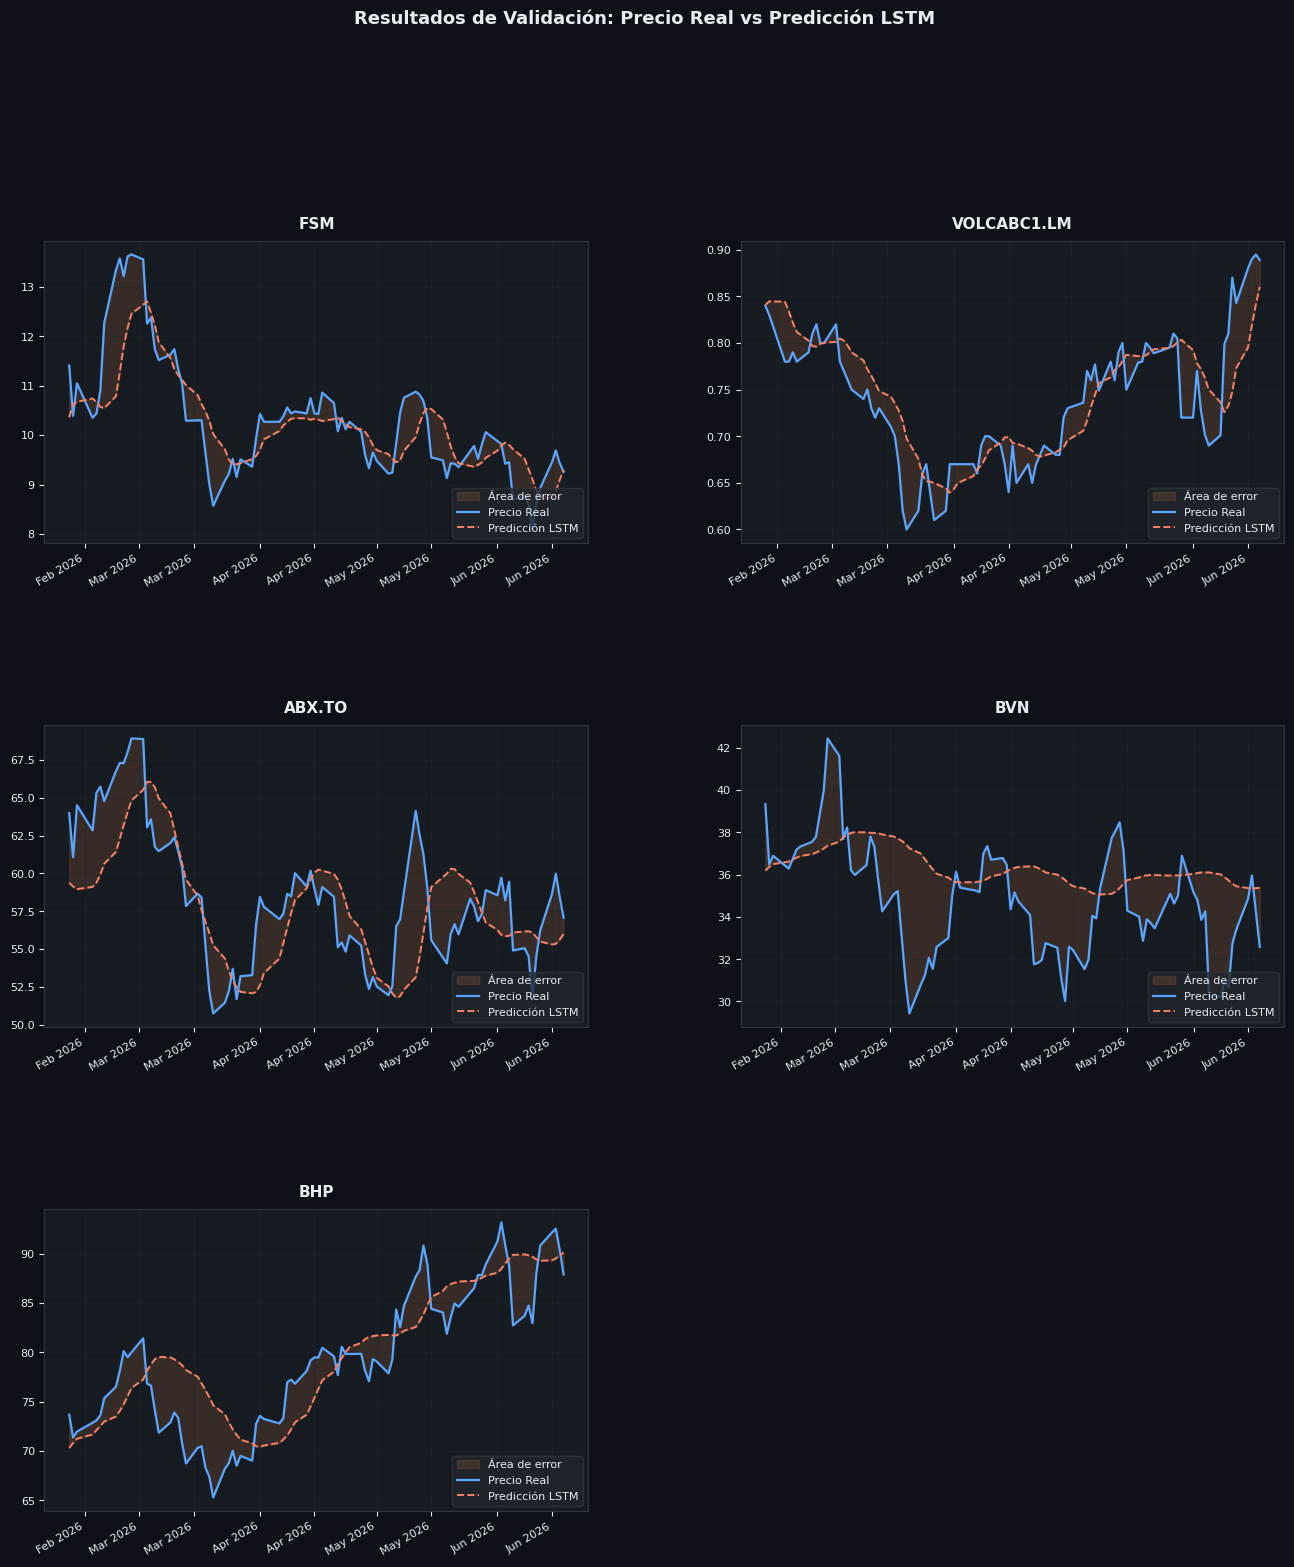

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — FASE 3: Panel de Visualización Estética en Modo Oscuro
# ─────────────────────────────────────────────────────────────────────────────
def plot_predictions(datasets: dict) -> None:
    BG_MAIN, BG_SUBPLOT = '#0d1117', '#161b22'
    C_REAL, C_PRED, C_AREA = '#58a6ff', '#f78166', '#f0883e'
    C_TEXT, C_GRID, C_BORDER = '#e6edf3', '#21262d', '#30363d'

    tickers_list = list(datasets.keys())
    nrows, ncols = int(np.ceil(len(tickers_list) / 2)), 2

    fig = plt.figure(figsize=(16, 5.5 * nrows), facecolor=BG_MAIN)
    fig.suptitle('Resultados de Validación: Precio Real vs Predicción LSTM', color=C_TEXT, fontsize=13, fontweight='bold', y=1.02)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.60, wspace=0.28)

    for i, ticker in enumerate(tickers_list):
        ax = fig.add_subplot(gs[i // ncols, i % ncols])
        ax.set_facecolor(BG_SUBPLOT)
        for spine in ax.spines.values():
            spine.set_edgecolor(C_BORDER)

        y_real = datasets[ticker]['y_test_real']
        y_pred = datasets[ticker]['y_pred_real']
        x_axis = pd.to_datetime(datasets[ticker]['dates_test'])

        ax.fill_between(x_axis, y_real, y_pred, alpha=0.15, color=C_AREA, label='Área de error')
        ax.plot(x_axis, y_real, color=C_REAL, linewidth=1.6, label='Precio Real')
        ax.plot(x_axis, y_pred, color=C_PRED, linewidth=1.4, linestyle='--', label='Predicción LSTM')

        ax.set_title(f'{ticker}', color=C_TEXT, fontsize=11, fontweight='bold', pad=9)
        ax.grid(True, color=C_GRID, linestyle='-', linewidth=0.5, alpha=0.75)
        ax.tick_params(colors=C_TEXT, labelsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color=C_TEXT)
        ax.legend(loc='lower right', fontsize=8, facecolor='#21262d', edgecolor=C_BORDER, labelcolor=C_TEXT)

    for j in range(len(tickers_list), nrows * ncols):
        fig.add_subplot(gs[j // ncols, j % ncols]).set_visible(False)

    plt.show()

plot_predictions(datasets)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — FASE 3: Exportación Estructurada a JSON para Frontend
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_JSON = 'lstm_regressor_data.json'

def export_to_json(datasets: dict, metrics_all: dict, output_path: str = OUTPUT_JSON) -> dict:
    metadata = {
        "proyecto": "Pronóstico de Precios — Acciones Mineras con Operaciones en Perú",
        "version": "1.0.0",
        "modelo": "Regresor LSTM (Stacked LSTM + Dropout + Dense)",
        "generado_en": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        "tickers": list(datasets.keys())
    }

    series = {}
    for ticker, data in datasets.items():
        y_real = data['y_test_real']
        y_pred = data['y_pred_real']
        fechas_str = data['dates_test']
        n_min = min(len(fechas_str), len(y_real), len(y_pred))

        series[ticker] = {
            "fechas": fechas_str[:n_min],
            "precio_real": [round(float(v), 4) for v in y_real[:n_min]],
            "precio_prediccion": [round(float(v), 4) for v in y_pred[:n_min]],
            "n_muestras": int(n_min)
        }

    json_payload = {"metadata": metadata, "metricas": metrics_all, "series": series}
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(json_payload, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Archivo '{output_path}' exportado correctamente para el Frontend.")
    return json_payload

json_payload = export_to_json(datasets, metrics_all, output_path=OUTPUT_JSON)


✅ Archivo 'lstm_regressor_data.json' exportado correctamente para el Frontend.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 12 — FASE 3: Validación Estructural del Artefacto JSON
# ─────────────────────────────────────────────────────────────────────────────
def validate_json_output(output_path: str = OUTPUT_JSON) -> None:
    with open(output_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    print("\n" + "=" * 66)
    print("  VALIDACIÓN DEL ARTEFACTO JSON")
    print("=" * 66)

    required = ['metadata', 'metricas', 'series']
    if all(s in data for s in required):
        print(f"  [✅] Estructura raíz correcta: {list(data.keys())}")

    for ticker, s in data['series'].items():
        if len(s['fechas']) == len(s['precio_real']) == len(s['precio_prediccion']):
            print(f"  [✅] {ticker:<12} → Arrays perfectamente alineados ({len(s['fechas'])} muestras).")
        else:
            print(f"  [❌] {ticker:<12} → Error de desalineación en los datos.")
    print("\n  🟢 Validación exitosa. Datos listos para producción.")
    print("=" * 66)

validate_json_output(OUTPUT_JSON)


  VALIDACIÓN DEL ARTEFACTO JSON
  [✅] Estructura raíz correcta: ['metadata', 'metricas', 'series']
  [✅] FSM          → Arrays perfectamente alineados (89 muestras).
  [✅] VOLCABC1.LM  → Arrays perfectamente alineados (87 muestras).
  [✅] ABX.TO       → Arrays perfectamente alineados (89 muestras).
  [✅] BVN          → Arrays perfectamente alineados (89 muestras).
  [✅] BHP          → Arrays perfectamente alineados (89 muestras).

  🟢 Validación exitosa. Datos listos para producción.
